# Phase 1 Environment Testing

This notebook is the dedicated test bench for the environment layer only.

Scope for this notebook:
- Board generation and role counts
- Different board-size variations
- Embedding store behavior used by the environment
- Reward helper behavior
- `CodenamesGame` and `CodenamesSpymasterEnv` reset/step smoke tests

Out of scope for this notebook:
- Agent training
- SAC / HER pipeline testing
- Baseline policy evaluation
- End-to-end experiment runs

## What This Notebook Is Trying to Prove

The main goal is to check that the environment layer is internally consistent before we spend time training agents on top of it. If these low-level pieces are wrong, the RL loop may still run, but it will learn from incorrect transitions, invalid rewards, or broken action decoding.

In practice, the most important things to test here are:
- Structural invariants: board size, role counts, and observation dimensions should match configuration.
- State transitions: reset and step should return valid observations and update board state predictably.
- Action plumbing: encoded actions should decode back into a clue/count pair with the expected shape.
- Reward plumbing: shaped reward and goal-conditioned reward should agree with the environment's step output.
- Cross-size robustness: the same code path should work for 2x2, 3x3, and 5x5 boards, not just the default board.

In [39]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.env.board import (
    BoardConfig,
    board_role_table,
    generate_board,
    get_available_indices,
    load_words,
    make_standard_config,
    remaining_indices_by_role,
    reveal_cell_by_index,
    summarize_roles,
)
from src.env.game import CodenamesGame, CodenamesSpymasterEnv
from src.env.reward import (
    RewardConfig,
    build_step_reward,
    clue_margin,
    compute_goal_conditioned_reward,
)
from src.env.visualization import plot_board
from src.utils.embeddings import EmbeddingStore

pd.set_option("display.max_colwidth", 120)

In [40]:
WORDS_PATH = PROJECT_ROOT / "data" / "raw" / "codenames_words.txt"
CLUES_PATH = PROJECT_ROOT / "data" / "raw" / "hints.txt"

all_words = load_words(WORDS_PATH)
print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded {len(all_words)} board words from {WORDS_PATH}")
print(f"Clue word file: {CLUES_PATH}")

Project root: /Users/aeshagandhi/Downloads/MIDS-Sp26/RL/Codenames-Spymaster-RL-fresh
Loaded 400 board words from /Users/aeshagandhi/Downloads/MIDS-Sp26/RL/Codenames-Spymaster-RL-fresh/data/raw/codenames_words.txt
Clue word file: /Users/aeshagandhi/Downloads/MIDS-Sp26/RL/Codenames-Spymaster-RL-fresh/data/raw/hints.txt


## Helpers

Small utilities below keep the notebook readable while we sweep board sizes and environment behavior.

These helpers are not the thing we are testing directly. They are wrappers that make it easier to inspect invariants in a compact way:
- `board_summary_row(...)` turns a generated board into a single validation row.
- `sample_indices_by_role(...)` gives us one example cell from each role so reveal logic can be checked quickly.
- `build_env(...)` standardizes environment creation so every sweep uses the same assumptions.
- `env_smoke_step(...)` performs one reset and one sampled step, which is the smallest useful end-to-end environment test.

In [41]:
BOARD_CONFIGS = {
    "2x2": make_standard_config(2, 2, seed=7),
    "3x3": make_standard_config(3, 3, seed=11),
    "5x5": make_standard_config(5, 5, seed=19),
}

def board_summary_row(name: str, config: BoardConfig, board):
    counts = summarize_roles(board)
    available = get_available_indices(board)
    return {
        "board_name": name,
        "shape": f"{config.rows}x{config.cols}",
        "board_size": config.board_size,
        "friendly": counts["friendly"],
        "opponent": counts["opponent"],
        "neutral": counts["neutral"],
        "assassin": counts["assassin"],
        "available_actions": len(available),
        "seed": config.seed,
    }

def sample_indices_by_role(board):
    picked = {}
    for role in ["friendly", "opponent", "neutral", "assassin"]:
        indices = remaining_indices_by_role(board, role)
        picked[role] = indices[0] if indices else None
    return picked

def build_env(config: BoardConfig, embedding_store: EmbeddingStore, seed: int):
    return CodenamesSpymasterEnv(
        board_words_path=str(WORDS_PATH),
        clue_words_path=str(CLUES_PATH),
        embedding_store=embedding_store,
        board_config=config,
        reward_config=RewardConfig(),
        embedding_dim=embedding_store.dimension,
        max_turns=6,
        max_clue_count=4,
        goal_size=2,
        seed=seed,
    )

def env_smoke_step(env: CodenamesSpymasterEnv, rng_seed: int = 123):
    obs, info = env.reset(seed=rng_seed)
    action = env.sample_action(np.random.RandomState(rng_seed))
    next_obs, reward, terminated, truncated, step_info = env.step(action)
    return {
        "obs_shape": obs["observation"].shape,
        "goal_shape": obs["desired_goal"].shape,
        "legal_clues": int(len(env.legal_clue_indices)),
        "sampled_action_shape": action.shape,
        "reward": float(reward),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "clue": step_info["clue"],
        "count": int(step_info["count"]),
        "guessed_roles": step_info["guessed_roles"],
        "friendly_remaining": int(step_info["friendly_remaining"]),
        "board_words_preview": info["board_words"][: min(5, len(info["board_words"]))],
        "next_obs_shape": next_obs["observation"].shape,
    }

## 1. Board Generation Across Size Variations

This verifies that each supported preset produces the expected shape, role counts, and unrevealed action space.

Why this matters:
- Board generation is the foundation for every later transition and reward calculation.
- If role counts drift, the game difficulty and target distribution change immediately.
- If unrevealed indices are wrong at reset, the action space and guessing logic are already corrupted before the first step.

Best things to inspect in this section:
- `board_size` should equal `rows * cols`.
- Role counts should sum to the full board size.
- `available_actions` should equal the number of unrevealed cells immediately after generation.
- The player view and spymaster view should contain the same words, but only the spymaster view should reveal roles.

In [42]:
generated_boards = {}
board_rows = []

for name, config in BOARD_CONFIGS.items():
    board = generate_board(all_words, config)
    generated_boards[name] = board
    board_rows.append(board_summary_row(name, config, board))

board_summary_df = pd.DataFrame(board_rows)
board_summary_df

,board_name,shape,board_size,friendly,opponent,neutral,assassin,available_actions,seed
0,2x2,2x2,4,1,1,1,1,4,7
1,3x3,3x3,9,3,2,3,1,9,11
2,5x5,5x5,25,8,8,8,1,25,19


In [43]:
selected_board_name = "5x5"
selected_board = generated_boards[selected_board_name]

pd.DataFrame(board_role_table(selected_board)).head(10)

,row,col,word,role,revealed,guess_order
0,0,0,STREAM,opponent,False,None
1,0,1,BATTERY,opponent,False,None
2,0,2,PITCH,neutral,False,None
3,0,3,CELL,neutral,False,None
4,0,4,PIN,neutral,False,None
5,1,0,DIAMOND,friendly,False,None
6,1,1,LION,opponent,False,None
7,1,2,JACK,neutral,False,None
8,1,3,PLATYPUS,friendly,False,None
9,1,4,GLOVE,friendly,False,None


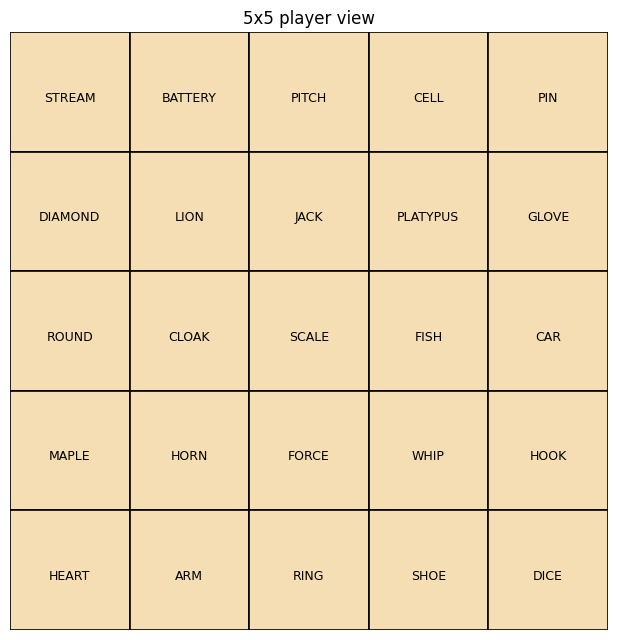

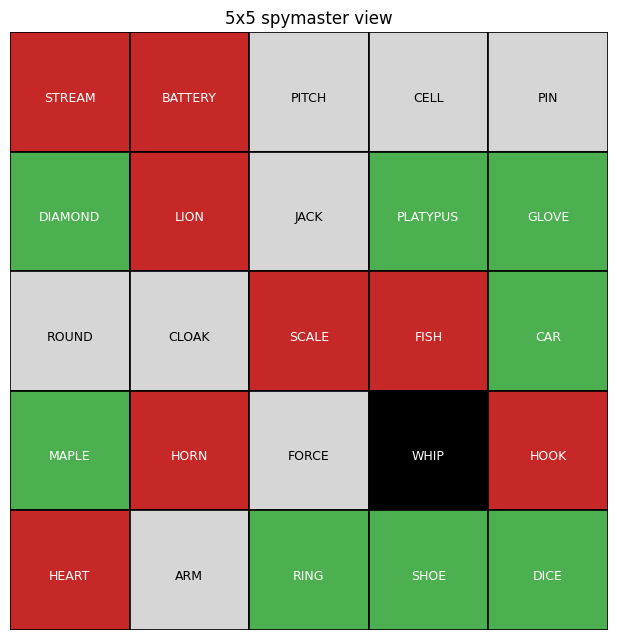

In [44]:
plot_board(
    selected_board,
    reveal_roles=False,
    title=f"{selected_board_name} player view",
    figsize_scale=1.3,
    font_size=9,
)

plot_board(
    selected_board,
    reveal_roles=True,
    title=f"{selected_board_name} spymaster view",
    figsize_scale=1.3,
    font_size=9,
)

Below, checks that reveal behavior is working correctly. If you ask for one friendly, one opponent, one neutral, and one assassin cell, the revealed cells should come back with matching actual_role values, and guess_order should increase each time. So this is basically a smoke test for “can the board reveal cells correctly and track reveal order?”

In [45]:
game = CodenamesGame(words=all_words, config=make_standard_config(3, 3, seed=31))
board = game.reset()
picked = sample_indices_by_role(board)

reveal_log = []
for role, idx in picked.items():
    if idx is None:
        continue
    cell = reveal_cell_by_index(board, idx)
    reveal_log.append({
        "role_targeted": role,
        "revealed_index": idx,
        "word": cell.word,
        "actual_role": cell.role,
        "guess_order": cell.guess_order,
    })

pd.DataFrame(reveal_log)

,role_targeted,revealed_index,word,actual_role,guess_order
0,friendly,2,CARROT,friendly,1
1,opponent,0,AMBULANCE,opponent,2
2,neutral,1,OCTOPUS,neutral,3
3,assassin,5,CHURCH,assassin,4


## 2. Embedding Store Smoke Test

The environment relies on clue and board embeddings, action encoding/decoding, and legal clue filtering.

What is happening here:
- The embedding store loads vector representations for board words and clue words.
- An action is represented as a continuous vector plus a count component.
- The environment later decodes that action back into a discrete clue/count choice.

Best things to test in this section:
- Embedding matrices should have the expected number of rows and the configured embedding dimension.
- Encoded actions should always have a stable shape.
- Decoding should return a valid clue token and a count within the configured maximum.
- If legal clue filtering is enabled later, decoding should respect the legal subset rather than the full clue vocabulary.

In [46]:
embedding_store = EmbeddingStore.from_paths(
    board_words_path=WORDS_PATH,
    clue_words_path=CLUES_PATH,
    dimension=64,
    persist_clues=False,
)

encoded = embedding_store.encode_action("flower", count=2, max_count=4)
decoded = embedding_store.decode_action(encoded, legal_indices=None, max_count=4)

pd.Series({
    "embedding_dim": embedding_store.dimension,
    "num_board_words": len(embedding_store.board_words),
    "num_clue_words": len(embedding_store.clue_words),
    "board_embedding_shape": embedding_store.board_embeddings.shape,
    "clue_embedding_shape": embedding_store.clue_embeddings.shape,
    "encoded_action_shape": encoded.shape,
    "decoded_clue": decoded[0],
    "decoded_count": decoded[1],
})

embedding_dim                    64
num_board_words                 400
num_clue_words                 8000
board_embedding_shape     (400, 64)
clue_embedding_shape     (8000, 64)
encoded_action_shape          (65,)
decoded_clue                 flower
decoded_count                     2
dtype: object

## 3. Reward Function Smoke Test

We compute a clue margin from sampled friendly vs. bad embeddings and then build both step reward and goal-conditioned reward outputs.

What is happening here:
- We compare one clue embedding against target-friendly words and against bad words.
- That comparison produces a margin, which acts like a semantic quality signal for the clue.
- The margin is then combined with task progress signals to form the final reward used by the environment and HER-style goal relabeling.

Best things to test in this section:
- Better clues should generally produce higher margins than obviously bad clues.
- Hitting the assassin should dominate the reward with a strong penalty.
- The reward breakdown should be easy to reconcile with the total scalar reward.
- `compute_goal_conditioned_reward(...)` should stay aligned with the non-goal reward fields emitted by environment steps.

In [47]:
reward_board = generated_boards["5x5"]
reward_flat = [cell for row in reward_board for cell in row]

friendly_words = [cell.word for cell in reward_flat if cell.role == "friendly"][:2]
bad_words = [cell.word for cell in reward_flat if cell.role in {"opponent", "neutral"}][:2]
assassin_word = next(cell.word for cell in reward_flat if cell.role == "assassin")

target_embeddings = embedding_store.matrix(friendly_words)
non_assassin_bad_embeddings = embedding_store.matrix(bad_words)
all_bad_embeddings = embedding_store.matrix(bad_words + [assassin_word])

reward_config = RewardConfig(turn_penalty=-1.0, assassin_penalty=-25.0, shaped_weight=1.0)

reward_cases = [
    {
        "case": "good clue, partial progress",
        "clue": friendly_words[0].lower(),
        "achieved_goal": np.array([1, 0, 0, 0], dtype=np.float32),
        "desired_goal": np.array([1, 1, 0, 0], dtype=np.float32),
        "assassin_hit": False,
        "bad_embeddings": all_bad_embeddings,
    },
    {
        "case": "bad clue, partial progress",
        "clue": assassin_word.lower(),
        "achieved_goal": np.array([1, 0, 0, 0], dtype=np.float32),
        "desired_goal": np.array([1, 1, 0, 0], dtype=np.float32),
        "assassin_hit": False,
        "bad_embeddings": all_bad_embeddings,
    },
    {
        "case": "assassin hit",
        "clue": assassin_word.lower(),
        "achieved_goal": np.array([1, 0, 0, 1], dtype=np.float32),
        "desired_goal": np.array([1, 1, 0, 0], dtype=np.float32),
        "assassin_hit": True,
        "bad_embeddings": non_assassin_bad_embeddings,
    },
]

reward_rows = []
for case in reward_cases:
    margin = clue_margin(
        clue_embedding=embedding_store.vector(case["clue"]),
        target_embeddings=target_embeddings,
        bad_embeddings=case["bad_embeddings"],
    )

    reward_without_goal = margin + (reward_config.assassin_penalty if case["assassin_hit"] else 0.0)

    reward_breakdown = build_step_reward(
        achieved_goal=case["achieved_goal"],
        desired_goal=case["desired_goal"],
        reward_without_goal=reward_without_goal,
        clue_margin_value=margin,
        assassin_hit=case["assassin_hit"],
        config=reward_config,
    )

    goal_conditioned_reward = compute_goal_conditioned_reward(
        achieved_goal=case["achieved_goal"],
        desired_goal=case["desired_goal"],
        info={"reward_without_goal": reward_without_goal},
        config=reward_config,
    )

    reward_rows.append({
        "case": case["case"],
        "clue": case["clue"],
        "friendly_words": friendly_words,
        "bad_words": bad_words,
        "assassin_word": assassin_word,
        "clue_margin": margin,
        "assassin_hit": case["assassin_hit"],
        "reward_without_goal": reward_without_goal,
        "step_reward_total": reward_breakdown.total,
        "goal_reward": reward_breakdown.goal_reward,
        "goal_achieved": reward_breakdown.goal_achieved,
        "goal_conditioned_reward": goal_conditioned_reward,
    })

pd.DataFrame(reward_rows)

,case,clue,friendly_words,bad_words,assassin_word,clue_margin,assassin_hit,reward_without_goal,step_reward_total,goal_reward,goal_achieved,goal_conditioned_reward
0,"good clue, partial progress",diamond,"[DIAMOND, PLATYPUS]","[STREAM, BATTERY]",WHIP,-0.069121,False,-0.069121,-1.069121,-1.0,False,-1.069121
1,"bad clue, partial progress",whip,"[DIAMOND, PLATYPUS]","[STREAM, BATTERY]",WHIP,-1.020915,False,-1.020915,-2.020915,-1.0,False,-2.020915
2,assassin hit,whip,"[DIAMOND, PLATYPUS]","[STREAM, BATTERY]",WHIP,-0.022691,True,-25.022691,-26.022691,-1.0,False,-26.022691


## 4. `CodenamesSpymasterEnv` Smoke Test Across Board Sizes

This checks reset/step behavior, observation shapes, clue decoding, and reward output for each board-size preset.

This is the closest thing in the notebook to a real environment integration test. It connects board generation, embeddings, action decoding, guessing, reward construction, and termination logic in one pass.

Best things to inspect in this section:
- Observation length should scale with board size, while action length should stay fixed.
- Goal vectors should match the number of board cells for that configuration.
- `terminated` should only become `True` when the environment actually reaches an end condition.
- `friendly_remaining`, `guessed_roles`, and `reward_breakdown` should tell a coherent story about what happened during the step.
- Running the same smoke step across multiple board sizes is useful because shape bugs often only appear away from the default configuration.

In [48]:
env_rows = []

for i, (name, config) in enumerate(BOARD_CONFIGS.items(), start=1):
    env = build_env(config=config, embedding_store=embedding_store, seed=100 + i)
    result = env_smoke_step(env, rng_seed=200 + i)
    env_rows.append({"board_name": name, **result})

env_summary_df = pd.DataFrame(env_rows)
env_summary_df

,board_name,obs_shape,goal_shape,legal_clues,sampled_action_shape,reward,terminated,truncated,clue,count,guessed_roles,friendly_remaining,board_words_preview,next_obs_shape
0,2x2,"(294,)","(4,)",8000,"(65,)",0.006523,True,False,shewel,2,"[friendly, opponent]",0,"[SWING, GHOST, RAY, POINT]","(294,)"
1,3x3,"(704,)","(9,)",8000,"(65,)",-1.327594,False,False,desmid,4,"[friendly, opponent]",2,"[STAR, RACKET, DIAMOND, BOW, NUT]","(704,)"
2,5x5,"(2352,)","(25,)",8000,"(65,)",-1.185669,False,False,miffed,2,[neutral],8,"[DAY, BOX, TICK, SCALE, CONCERT]","(2352,)"


In [49]:
env = build_env(config=make_standard_config(5, 5, seed=77), embedding_store=embedding_store, seed=77)
obs, info = env.reset(seed=77)
action = env.sample_action(np.random.RandomState(77))
next_obs, reward, terminated, truncated, step_info = env.step(action)

pd.Series({
    "observation_len": len(obs["observation"]),
    "achieved_goal_len": len(obs["achieved_goal"]),
    "desired_goal_len": len(obs["desired_goal"]),
    "decoded_action": env.last_decoded_action,
    "reward": reward,
    "terminated": terminated,
    "truncated": truncated,
    "goal_words": step_info["goal_words"],
    "guessed_words": step_info["guessed_words"],
    "guessed_roles": step_info["guessed_roles"],
    "reward_breakdown": step_info["reward_breakdown"],
})

observation_len                                                                                                                         2352
achieved_goal_len                                                                                                                         25
desired_goal_len                                                                                                                          25
decoded_action                                                                                                {'clue': 'flurry', 'count': 4}
reward                                                                                                                              -1.16298
terminated                                                                                                                             False
truncated                                                                                                                              False
goal_words   

## 5. How To Read Failures In This Notebook

A quick way to diagnose failures:
- Wrong role counts or board size usually points to `make_standard_config(...)`, board sampling, or role assignment logic.
- Wrong observation or goal shapes usually points to feature construction inside the environment rather than board generation.
- Strange decoded clues or count values usually points to action encoding/decoding or legal clue filtering.
- Reward totals that do not match the breakdown usually point to reward helper logic, not the board itself.
- Termination inconsistencies usually point to step logic, guessed-role handling, or friendly/assassin bookkeeping.

## 6. Best Additional Tests To Add Later

This notebook is a strong smoke-test pass, but the next high-value tests would be:
- Determinism checks: same seed should reproduce the same board and reset behavior.
- Illegal clue checks: clues that match board words, banned forms, or filtered clues should be rejected consistently.
- Edge-case reward checks: assassin hit, zero guesses, all-friendly completion, and truncated episodes.
- Property-style checks: role counts should remain valid across many random seeds, not just one per board size.
- Regression tests in `pytest`: once a notebook result looks correct, the invariant should usually graduate into an automated unit or integration test.